In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input

In [4]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4711, 60, 1) (4711,)
(1133, 60, 1) (1133,)


In [5]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], 1)))

model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

In [6]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 29s 119ms/step - loss: 0.0094 - val_loss: 0.0362
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - loss: 0.0022 - val_loss: 0.0150
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - loss: 0.0020 - val_loss: 0.0228
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0016 - val_loss: 0.0204
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - loss: 0.0016 - val_loss: 0.0204
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - loss: 0.0015 - val_loss: 0.0303
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - loss: 0.0014 - val_loss: 0.0159
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - loss: 0.0015 - val_loss: 0.0191
Epoch 9/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - loss: 0.0011 - val_loss: 0.0253
Epoch 10/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0013 - val_loss: 0.0145
Epoch 11/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - loss: 0.0011 - val_loss: 0.0169
Epoch 12/20
148/148 ━

In [8]:
predictions = model.predict(X_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step


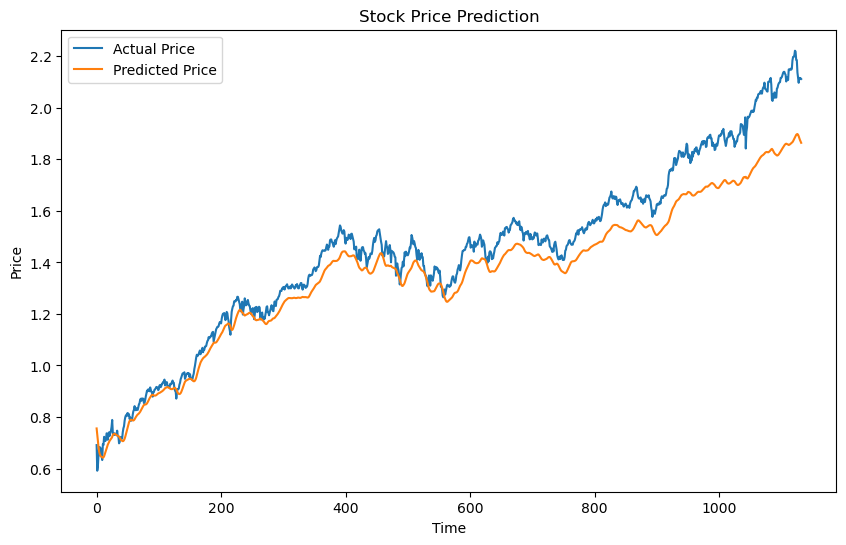

In [9]:
plt.figure(figsize=(10,6))

plt.plot(y_test, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

Mean Squared Error: 0.012468164501115427
Root Mean Squared Error: 0.11166093543005731
Mean Absolute Error: 0.0889410455399141


In [12]:
model.save("stock_model.keras")
print("model saved successfully")


model saved successfully


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.012468164501115427
RMSE: 0.11166093543005731
MAE: 0.0889410455399141


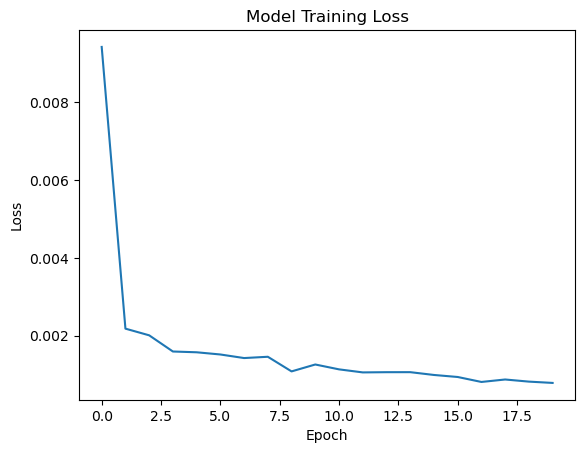

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [15]:
import pandas as pd

results = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": predictions.flatten()
})

results.to_csv("stock_predictions.csv", index=False)

print("Predictions Saved")

Predictions Saved
